In [8]:
library(data.table)
library(ggplot2)
library(ggpubr)

In [3]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code/mapping/analysis"

In [4]:
io = list()
io$main = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/'
io$mapping_all = file.path(io$main, '/results/rna/mapping/mapping_mnn_all_samples.txt.gz')
io$mapping_per = file.path(io$main, '/results/rna/mapping/sample_metadata_after_mapping.txt.gz')

In [11]:
mapping_all = fread(io$mapping_all)
mapping_per = fread(io$mapping_per)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 147984 rows containing non-finite values (stat_bin).”


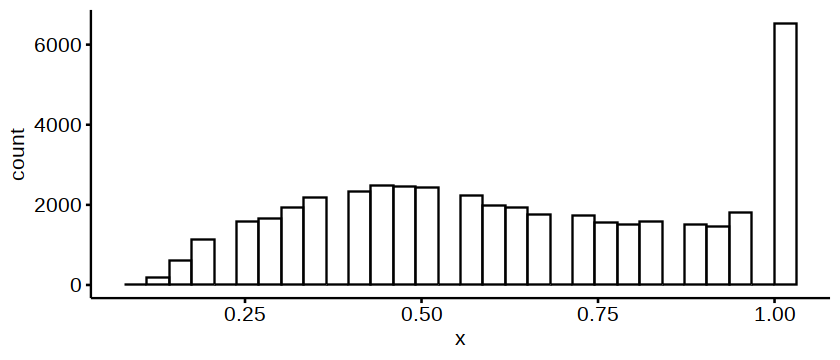

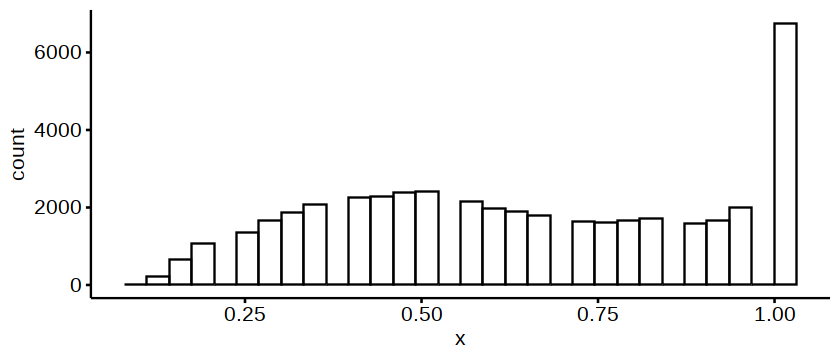

In [13]:
options(repr.plot.height=3)
gghistogram(mapping_all$celltype.score)
gghistogram(mapping_per$celltype.score)

In [35]:
compare = data.table(cell = mapping_all$cell, all = mapping_all$celltype.mapped, per = mapping_per[!is.na(celltype.mapped_mnn)]$celltype.mapped_mnn) %>%
    .[,count := .N, by=c('all', 'per')] %>%
    .[,tot := .N, by='all'] %>% .[,prop := count/tot] %>%
    unique(by=c('all', 'per')) 

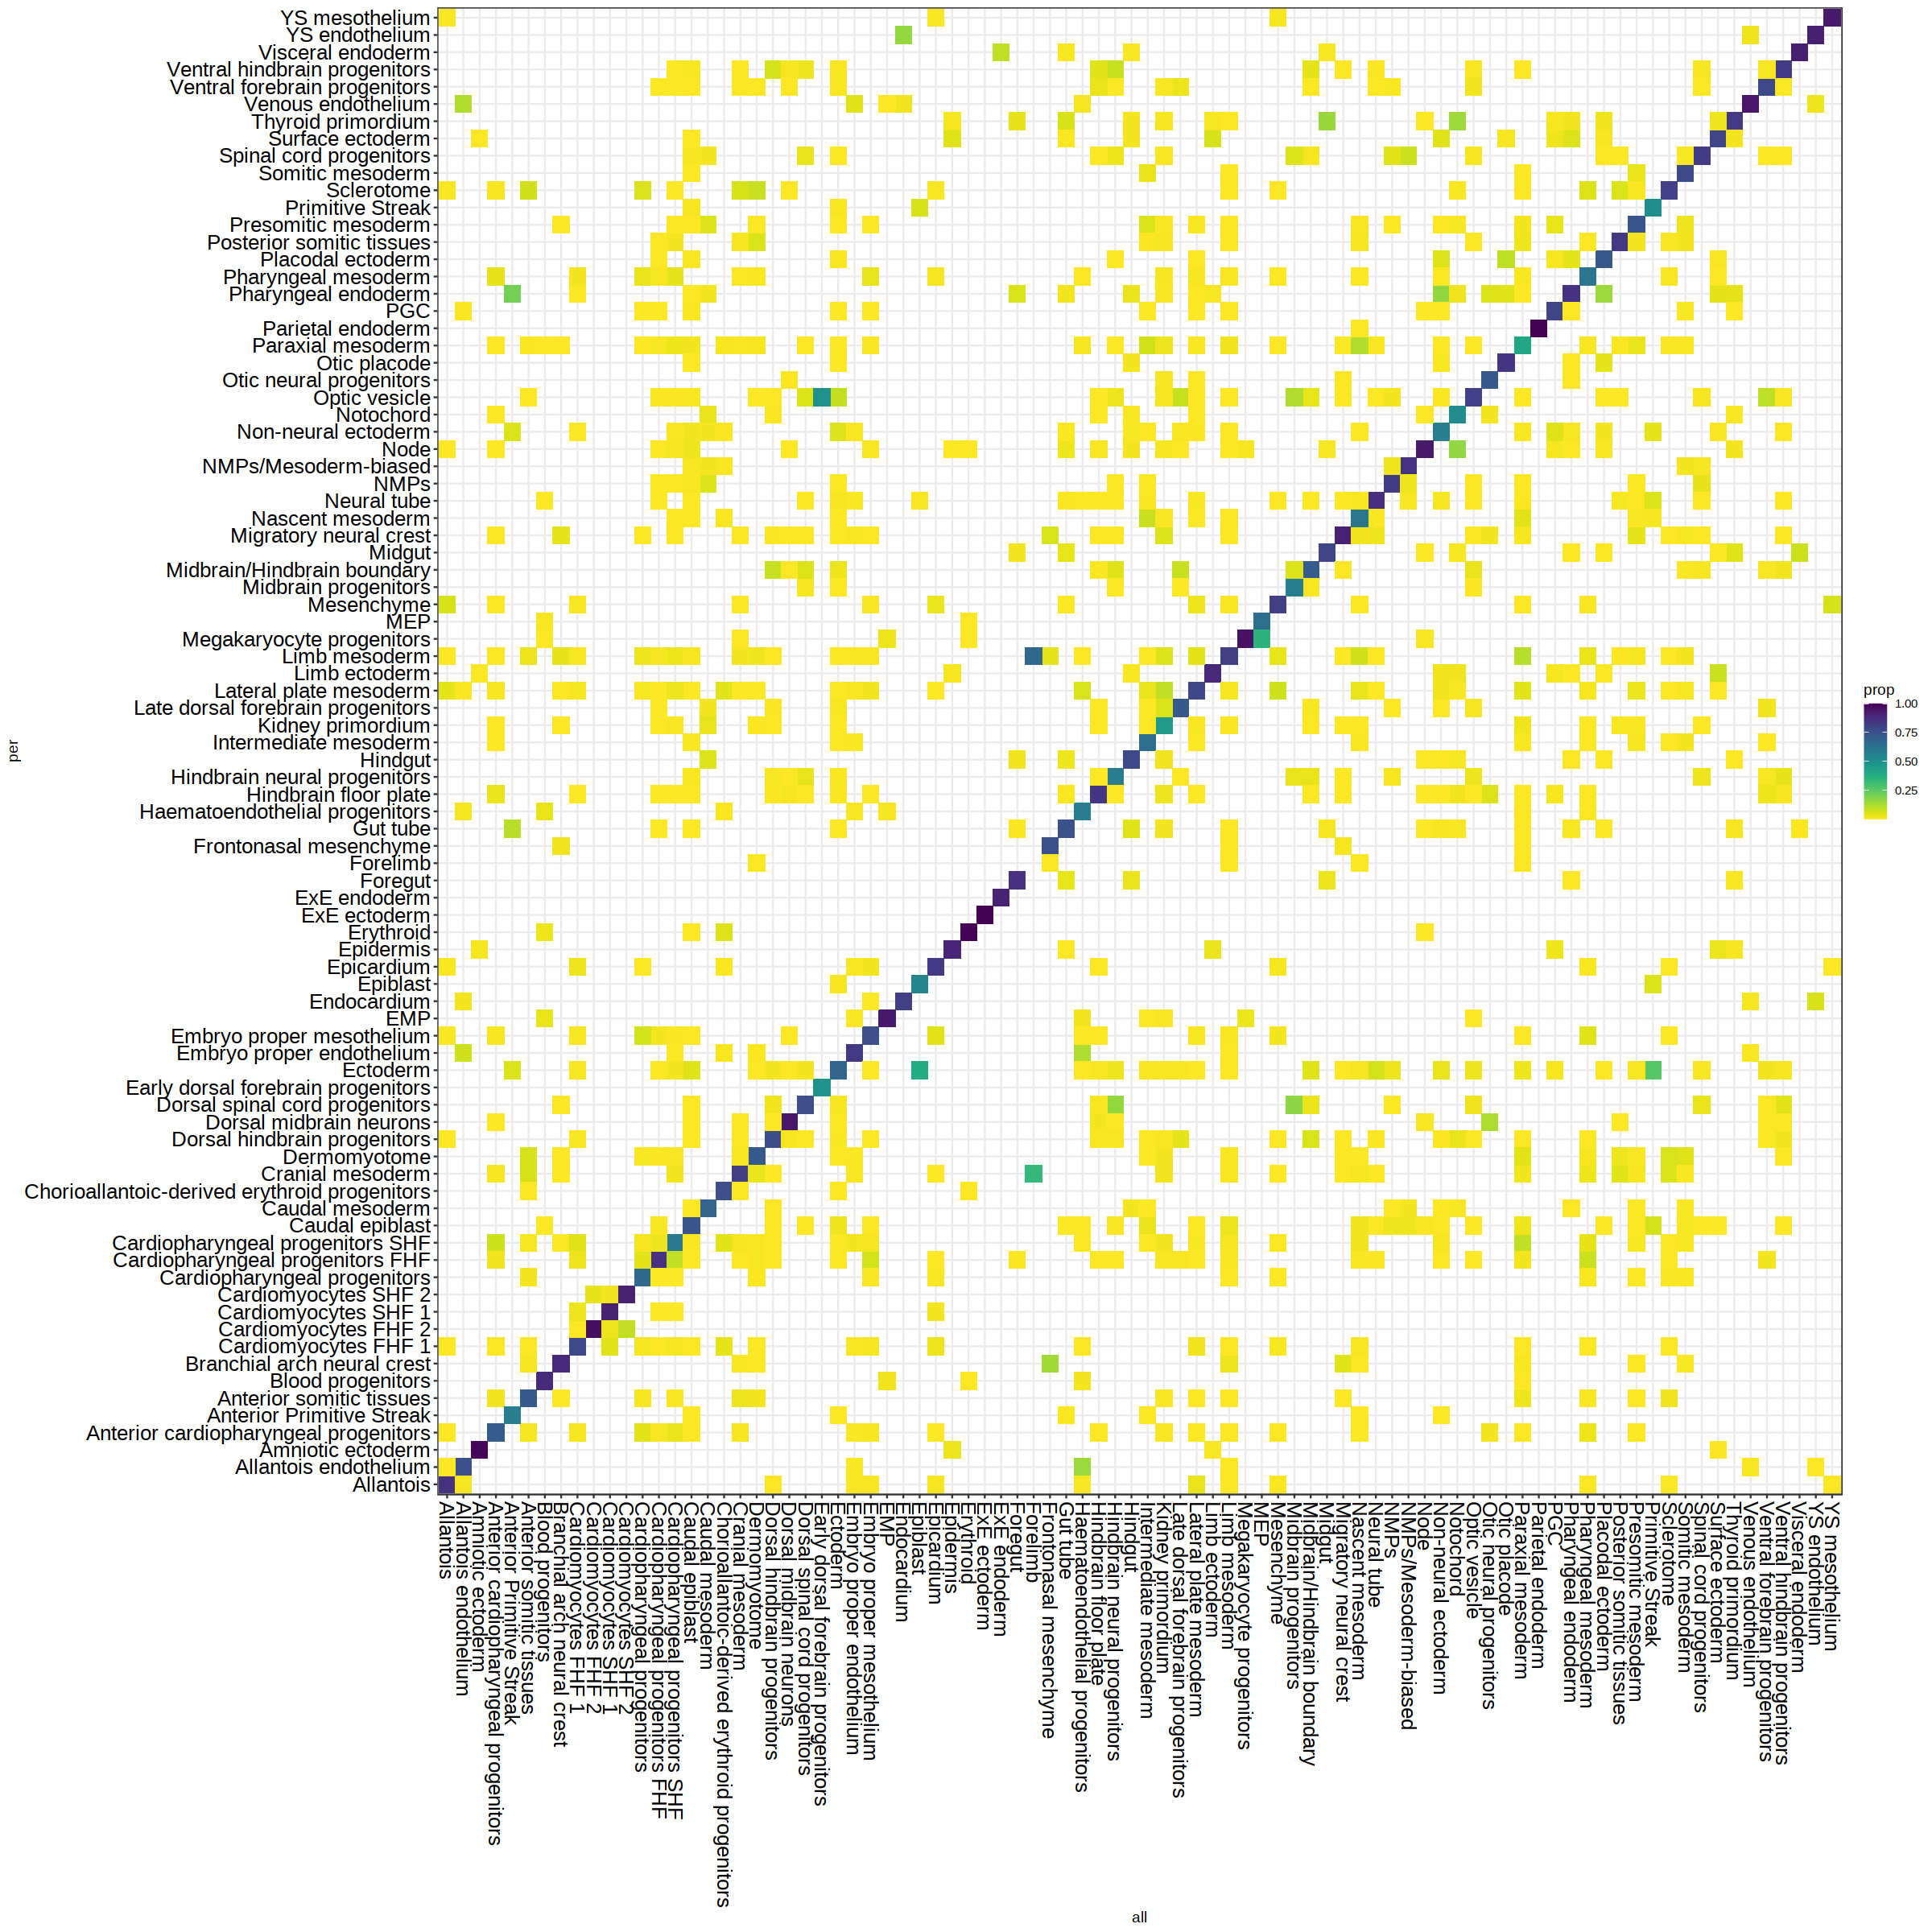

In [45]:
options(repr.plot.width=20, repr.plot.height=20)
ggplot(compare, aes(all, per, fill=prop)) + 
    geom_tile() + 
    viridis::scale_fill_viridis(begin=1, end=0) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.text = element_text(color='black', size=15))